# NB 10 — Cooperative Learning + LDA

**Comparaison rigoureuse avec NB09 (SGCCA + LDA)** sur le même protocole.

## Objet du notebook

Reproduire la philosophie de NB09 mais en remplaçant SGCCA par **Cooperative Learning** (Ding, Tibshirani, Hastie — *PNAS* 2022), le tout suivi d'une **LDA** sur les composantes latentes.

| | SGCCA (NB09) | Cooperative (NB10) |
|---|---|---|
| Réducteur de dim multi-bloc | ✓ | ✓ |
| Sparse par bloc (L1) | ✓ | ✓ |
| Critère optimisé | $\sum_{j,k} c_{jk}\,g(\text{cov}(X_j a_j, X_k a_k))$ | $\|y - X_{GE}\theta_{GE} - X_{CGH}\theta_{CGH}\|^2 + \rho\,\|X_{GE}\theta_{GE} - X_{CGH}\theta_{CGH}\|^2 + \lambda\,(\|\theta_{GE}\|_1 + \|\theta_{CGH}\|_1)$ |
| Force l'agrément entre blocs | non | **oui** (paramètre $\rho$) |
| Implémentation | `RGCCA::rgcca` | `multiview::cv.multiview` |

## Protocole CV (identique au paper, identique à NB09)

- 7-fold stratifié × 3 répétitions = 21 folds sur le **train**
- Grille sur $\rho$ : sélection externe
- Pour chaque $\rho$, `cv.multiview` choisit $\lambda$ en interne
- Refit sur tout le train au meilleur $\rho$
- Évaluation finale sur le **test set tenu à part**

> **Note CV** : le paper utilise du k-fold répété stratifié pour la sélection d'HP, **pas une vraie nested CV** comme dans NB07. Le test set tenu à part joue le rôle de la boucle externe. Pour comparer SGCCA et Cooperative à armes égales, on adopte ce protocole.


## 1. Setup

In [26]:
set.seed(42)
SEED <- 42
LABEL_ORDER <- c("cort", "dipg", "midl")

required_packages <- c("multiview", "data.table", "caret", "MASS")
to_install <- required_packages[!vapply(required_packages, requireNamespace,
                                        logical(1), quietly = TRUE)]
if (length(to_install) > 0) {
  install.packages(to_install, repos = "https://cloud.r-project.org")
}

suppressPackageStartupMessages({
  library(multiview)
  library(data.table)
  library(caret)
  library(MASS)
})

cat("multiview version:", as.character(packageVersion("multiview")), "\n")


multiview version: 0.8 


## 2. Chargement des données (identique à NB09)

Mêmes blocs, mêmes patients, même imputation médiane train-only.

In [27]:
root <- normalizePath(file.path(getwd()), winslash = "/", mustWork = FALSE)
data_dir <- if (dir.exists(file.path(root, "data"))) file.path(root, "data") else file.path(dirname(root), "data")

to_numeric_frame <- function(df) {
  rn <- rownames(df)
  out <- as.data.frame(
    lapply(df, function(x) as.numeric(gsub(",", ".", as.character(x), fixed = TRUE))),
    check.names = FALSE
  )
  rownames(out) <- rn
  out
}

extract_id_column <- function(df) {
  if ("row_id" %in% names(df)) return("row_id")
  names(df)[1]
}

load_block <- function(block_name, split) {
  path <- file.path(data_dir,
    sprintf("ge_cgh_locIGR__multiblocks__%s__%s.csv", block_name, split))
  df <- as.data.frame(data.table::fread(path, check.names = FALSE))
  id_col <- extract_id_column(df)
  rownames(df) <- as.character(df[[id_col]])
  df[[id_col]] <- NULL
  to_numeric_frame(df)
}

load_targets <- function(split) {
  path <- file.path(data_dir,
    sprintf("ge_cgh_locIGR__multiblocks__y__%s.csv", split))
  y_df <- as.data.frame(data.table::fread(path, check.names = FALSE))
  id_col <- extract_id_column(y_df)
  rownames(y_df) <- as.character(y_df[[id_col]])
  y_df[[id_col]] <- NULL
  targets <- factor(
    LABEL_ORDER[max.col(as.matrix(y_df[, LABEL_ORDER]), ties.method = "first")],
    levels = LABEL_ORDER
  )
  names(targets) <- rownames(y_df)
  targets
}

fill_missing_from_train <- function(train_df, test_df) {
  medians <- vapply(train_df, median, numeric(1), na.rm = TRUE)
  for (col in names(train_df)) {
    train_df[[col]][is.na(train_df[[col]])] <- medians[[col]]
    test_df[[col]][is.na(test_df[[col]])] <- medians[[col]]
  }
  list(train = train_df, test = test_df)
}

X_ge_train  <- load_block("GE",  "train")
X_ge_test   <- load_block("GE",  "test")
X_cgh_train <- load_block("CGH", "train")
X_cgh_test  <- load_block("CGH", "test")
y_train     <- load_targets("train")
y_test      <- load_targets("test")

train_ids <- Reduce(intersect, list(rownames(X_ge_train), rownames(X_cgh_train), names(y_train)))
test_ids  <- Reduce(intersect, list(rownames(X_ge_test),  rownames(X_cgh_test),  names(y_test)))

X_ge_train  <- X_ge_train [train_ids, , drop = FALSE]
X_cgh_train <- X_cgh_train[train_ids, , drop = FALSE]
y_train     <- y_train    [train_ids]
X_ge_test   <- X_ge_test  [test_ids,  , drop = FALSE]
X_cgh_test  <- X_cgh_test [test_ids,  , drop = FALSE]
y_test      <- y_test     [test_ids]

filled_ge  <- fill_missing_from_train(X_ge_train,  X_ge_test)
X_ge_train <- filled_ge$train;  X_ge_test  <- filled_ge$test
filled_cgh  <- fill_missing_from_train(X_cgh_train, X_cgh_test)
X_cgh_train <- filled_cgh$train; X_cgh_test <- filled_cgh$test

X_ge_train  <- as.matrix(X_ge_train)
X_ge_test   <- as.matrix(X_ge_test)
X_cgh_train <- as.matrix(X_cgh_train)
X_cgh_test  <- as.matrix(X_cgh_test)

cat(sprintf("Train: %d patients | Test: %d patients\n", length(y_train), length(y_test)))
cat(sprintf("GE: %d features | CGH: %d features\n",
            ncol(X_ge_train), ncol(X_cgh_train)))
print(table(train = y_train))
print(table(test  = y_test))


Train: 39 patients | Test: 14 patients
GE: 15702 features | CGH: 1229 features
train
cort dipg midl 
  15   16    8 
test
cort dipg midl 
   5    6    3 


## 3. Fonctions utilitaires

**Le coeur du protocole** :

1. `fit_coop_ovr_at_rho` : pour un $\rho$ donné, ajuste **K modèles cooperative binomiaux** (one-vs-rest), un par classe. Chaque modèle utilise `cv.multiview` pour sélectionner $\lambda$ en interne (5-fold).
2. `extract_block_scores` : extrait les coefficients par bloc à partir d'un fit `multiview` (les coefs sont concaténés à la sortie ; on les sépare en utilisant les dimensions des blocs).
3. `predict_coop_lda` : pour chaque modèle binomial, calcule `X_GE %*% beta_GE` et `X_CGH %*% beta_CGH` (les scores par bloc). Sortie : matrice n × (2K) — analogue aux composantes SGCCA, en plus haute dim.
4. `fit_coop_lda_pipeline` : enchaîne (1) + (3) + LDA sur les 2K scores → classifieur final.


In [28]:
# --- Extract per-block coefficients from a multiview fit at lambda.min ---
extract_block_coefs <- function(fit, x_list) {
  # multiview concatenates coefficients across views (intercept first)
  coef_all <- as.numeric(coef(fit, s = "lambda.min"))
  p_per_view <- vapply(x_list, ncol, integer(1))

  intercept <- coef_all[1]
  betas <- list()
  start <- 2
  for (j in seq_along(x_list)) {
    end <- start + p_per_view[j] - 1
    betas[[j]] <- coef_all[start:end]
    start <- end + 1
  }
  names(betas) <- names(x_list)
  list(intercept = intercept, betas = betas)
}

# --- Fit cooperative learning OvR at given rho, for K binary tasks ---
# Returns: list of K extracted coefficient sets (intercept + betas per view)
fit_coop_ovr_at_rho <- function(X_GE, X_CGH, y_factor, rho,
                                  nfolds_lambda = 5, verbose = FALSE) {
  K <- nlevels(y_factor)
  classes <- levels(y_factor)
  y_onehot <- model.matrix(~ y_factor - 1)
  colnames(y_onehot) <- classes

  x_list <- list(GE = X_GE, CGH = X_CGH)
  coefs_per_class <- vector("list", K)

  for (k in seq_len(K)) {
    yk <- y_onehot[, k]
    fit_k <- multiview::cv.multiview(
      x_list       = x_list,
      y            = yk,
      rho          = rho,
      family       = binomial(),
      type.measure = "deviance",
      nfolds       = nfolds_lambda,
      standardize  = TRUE
    )
    coefs_per_class[[k]] <- extract_block_coefs(fit_k, x_list)
    if (verbose) cat(sprintf("  rho=%.2f class=%s lambda.min=%.4f\n",
                              rho, classes[k], fit_k$lambda.min))
  }

  list(rho = rho, classes = classes, coefs_per_class = coefs_per_class)
}

# --- Compute block scores for new data ---
# Returns n × (2K) matrix: K scores from GE + K scores from CGH
compute_block_scores <- function(coop_fit, X_GE_new, X_CGH_new) {
  K <- length(coop_fit$coefs_per_class)
  n <- nrow(X_GE_new)
  scores <- matrix(0, n, 2 * K)
  for (k in seq_len(K)) {
    cfs <- coop_fit$coefs_per_class[[k]]
    scores[, k]     <- as.numeric(X_GE_new  %*% cfs$betas$GE)
    scores[, K + k] <- as.numeric(X_CGH_new %*% cfs$betas$CGH)
  }
  colnames(scores) <- c(
    paste0("GE_", coop_fit$classes),
    paste0("CGH_", coop_fit$classes)
  )
  scores
}

# --- Full pipeline: cooperative OvR + LDA ---
fit_coop_lda_pipeline <- function(X_GE, X_CGH, y_factor, rho,
                                   nfolds_lambda = 5, verbose = FALSE) {
  coop <- fit_coop_ovr_at_rho(X_GE, X_CGH, y_factor, rho,
                              nfolds_lambda = nfolds_lambda, verbose = verbose)
  scores_train <- compute_block_scores(coop, X_GE, X_CGH)

  # Diagnostic : compter les coefs non-nuls par (classe, bloc) pour reperer
  # les modeles binomiaux qui ont degenere (lambda trop grand -> beta = 0).
  nz_summary <- sapply(coop$coefs_per_class, function(cfs) {
    c(GE = sum(abs(cfs$betas$GE) > 1e-8),
      CGH = sum(abs(cfs$betas$CGH) > 1e-8))
  })
  colnames(nz_summary) <- coop$classes
  if (verbose) {
    cat("Non-zero coefs par classe/bloc :\n")
    print(nz_summary)
  }

  # Filtrer les colonnes constantes : si une classe a beta=0 pour un bloc,
  # le score correspondant est constant et casse LDA. On les retire.
  non_const <- apply(scores_train, 2, function(x) length(unique(x)) > 1)
  if (any(!non_const) && verbose) {
    message(sprintf("Drop %d colonne(s) constante(s) avant LDA: %s",
                    sum(!non_const),
                    paste(colnames(scores_train)[!non_const], collapse = ", ")))
  }
  if (sum(non_const) == 0) {
    stop("Toutes les colonnes de scores sont constantes : cooperative a entierement collapse. Reduire rho ou changer de lambda.")
  }
  if (sum(non_const) < 2) {
    warning("Moins de 2 colonnes non-constantes : LDA va etre tres pauvre.")
  }

  scores_train_use <- scores_train[, non_const, drop = FALSE]
  lda_fit <- MASS::lda(scores_train_use, grouping = y_factor)

  list(coop = coop, lda = lda_fit,
       scores_train = scores_train,
       non_const_mask = non_const,
       nz_summary = nz_summary)
}

predict_coop_lda <- function(pipeline, X_GE_new, X_CGH_new) {
  scores_new <- compute_block_scores(pipeline$coop, X_GE_new, X_CGH_new)
  scores_new_use <- scores_new[, pipeline$non_const_mask, drop = FALSE]
  pred <- predict(pipeline$lda, newdata = scores_new_use)
  list(class = pred$class, posterior = pred$posterior, scores = scores_new)
}


## 4. Sanity check — ajustement unique à ρ = 0

Vérifie que le pipeline fonctionne end-to-end. À ρ = 0, on a essentiellement un Lasso multi-bloc sans contrainte d'agrément (équivalent fusion précoce naive avec sparsité par bloc).

⚠️ Cette cellule peut prendre **5-10 min** (3 cv.multiview à p ~ 17 000).

In [29]:
t0 <- Sys.time()
pipe_test <- fit_coop_lda_pipeline(
  X_ge_train, X_cgh_train, y_train,
  rho = 0, verbose = TRUE
)
elapsed <- difftime(Sys.time(), t0, units = "mins")
cat(sprintf("\nDurée fit unique (rho=0): %.1f min\n", as.numeric(elapsed)))

# Compter les variables sélectionnées (non-zéro) par bloc, par classe
cat("\nVariables sélectionnées (au moins 1 classe) :\n")
nz_ge <- 0; nz_cgh <- 0
for (k in seq_along(pipe_test$coop$coefs_per_class)) {
  cfs <- pipe_test$coop$coefs_per_class[[k]]
  nz_ge_k  <- sum(abs(cfs$betas$GE)  > 1e-8)
  nz_cgh_k <- sum(abs(cfs$betas$CGH) > 1e-8)
  cat(sprintf("  Classe %s : %d / %d gènes (GE), %d / %d régions (CGH)\n",
              pipe_test$coop$classes[k],
              nz_ge_k, ncol(X_ge_train),
              nz_cgh_k, ncol(X_cgh_train)))
}

# Prédiction quick sur le test set
pred_test <- predict_coop_lda(pipe_test, X_ge_test, X_cgh_test)
cm_test <- caret::confusionMatrix(
  factor(pred_test$class, levels = LABEL_ORDER),
  factor(y_test, levels = LABEL_ORDER)
)
cat("\n=== Test set (rho=0, sanity check) ===\n")
print(cm_test$table)
cat(sprintf("Accuracy: %.3f | Balanced accuracy moy.: %.3f\n",
            cm_test$overall["Accuracy"],
            mean(cm_test$byClass[, "Balanced Accuracy"])))


  rho=0.00 class=cort lambda.min=0.0038
  rho=0.00 class=dipg lambda.min=0.0121
  rho=0.00 class=midl lambda.min=0.2415
Non-zero coefs par classe/bloc :
    cort dipg midl
GE    24   18    0
CGH    0    0    0


Drop 4 colonne(s) constante(s) avant LDA: GE_midl, CGH_cort, CGH_dipg, CGH_midl




Durée fit unique (rho=0): 0.1 min

Variables sélectionnées (au moins 1 classe) :
  Classe cort : 24 / 15702 gènes (GE), 0 / 1229 régions (CGH)
  Classe dipg : 18 / 15702 gènes (GE), 0 / 1229 régions (CGH)
  Classe midl : 0 / 15702 gènes (GE), 0 / 1229 régions (CGH)

=== Test set (rho=0, sanity check) ===
          Reference
Prediction cort dipg midl
      cort    5    0    0
      dipg    0    6    1
      midl    0    0    2
Accuracy: 0.929 | Balanced accuracy moy.: 0.924


## 5. Cross-validation sur ρ (protocole NB09)

**7-fold stratifié × 3 répétitions = 21 folds sur le train**.

Pour chaque ρ candidat :
- Pour chaque fold (train_fold, val_fold)
  - Ajuster le pipeline cooperative + LDA sur train_fold
  - Prédire val_fold, calculer balanced accuracy
- Moyenne sur les 21 folds → score CV(ρ)

Sélection du meilleur ρ.

⚠️ Très coûteux : 21 folds × 6 valeurs de ρ × 3 modèles binomiaux × CV interne pour λ = ~378 fits.
**Compter 60-120 min selon la machine.**

In [30]:
rho_grid <- c(0, 0.1, 0.5, 1, 2, 5)

set.seed(SEED)
outer_folds <- caret::createMultiFolds(y_train, k = 7, times = 3)

cv_results <- data.frame()

for (rho_val in rho_grid) {
  cat(sprintf("\n=== rho = %.2f ===\n", rho_val))
  fold_scores <- numeric(length(outer_folds))
  t0_rho <- Sys.time()

  for (i in seq_along(outer_folds)) {
    tr_idx <- outer_folds[[i]]
    va_idx <- setdiff(seq_along(y_train), tr_idx)

    pipe_fold <- tryCatch(
      fit_coop_lda_pipeline(
        X_ge_train[tr_idx, , drop = FALSE],
        X_cgh_train[tr_idx, , drop = FALSE],
        y_train[tr_idx],
        rho = rho_val,
        verbose = FALSE
      ),
      error = function(e) { message("  fold ", i, " failed: ", conditionMessage(e)); NULL }
    )
    if (is.null(pipe_fold)) { fold_scores[i] <- NA_real_; next }

    pred_va <- predict_coop_lda(
      pipe_fold,
      X_ge_train[va_idx, , drop = FALSE],
      X_cgh_train[va_idx, , drop = FALSE]
    )
    cm <- caret::confusionMatrix(
      factor(pred_va$class, levels = LABEL_ORDER),
      factor(y_train[va_idx], levels = LABEL_ORDER)
    )
    fold_scores[i] <- mean(cm$byClass[, "Balanced Accuracy"], na.rm = TRUE)
  }

  elapsed <- difftime(Sys.time(), t0_rho, units = "mins")
  cat(sprintf("  Bal_acc moy = %.3f ± %.3f  (%.1f min)\n",
              mean(fold_scores, na.rm = TRUE),
              sd(fold_scores, na.rm = TRUE),
              as.numeric(elapsed)))

  cv_results <- rbind(cv_results, data.frame(
    rho = rho_val,
    mean_bal_acc = mean(fold_scores, na.rm = TRUE),
    sd_bal_acc   = sd(fold_scores, na.rm = TRUE),
    n_folds      = sum(!is.na(fold_scores))
  ))
}

cat("\n========== RÉSULTATS CV ==========\n")
print(cv_results)



=== rho = 0.00 ===
  Bal_acc moy = 0.829 ± 0.148  (32.7 min)

=== rho = 0.10 ===


Warning message:
“glmnet.fit: algorithm did not converge”
Warning message:
“glmnet.fit: algorithm did not converge”
Warning message:
“glmnet.fit: algorithm did not converge”
Warning message:
“glmnet.fit: algorithm did not converge”
Warning message:
“glmnet.fit: algorithm did not converge”
Warning message:
“glmnet.fit: algorithm did not converge”
Warning message:
“glmnet.fit: algorithm did not converge”
Warning message:
“glmnet.fit: algorithm did not converge”
Warning message:
“glmnet.fit: algorithm did not converge”
Warning message:
“glmnet.fit: algorithm did not converge”
Warning message:
“glmnet.fit: algorithm did not converge”
Warning message:
“glmnet.fit: algorithm did not converge”
Warning message:
“glmnet.fit: algorithm did not converge”
Warning message:
“glmnet.fit: algorithm did not converge”
Warning message:
“glmnet.fit: algorithm did not converge”
Warning message:
“glmnet.fit: algorithm did not converge”
Warning message:
“glmnet.fit: algorithm did not converge”
Warning messag

In [31]:
print(cv_results)

  rho mean_bal_acc sd_bal_acc n_folds
1   0    0.8294974  0.1484916      21


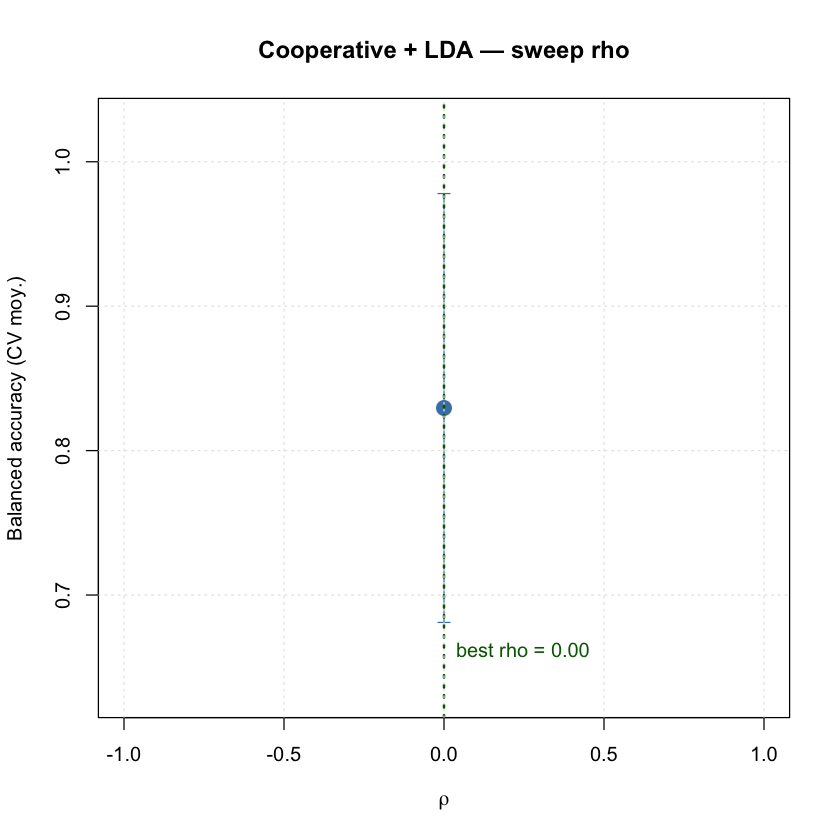

In [32]:
# Visualisation du sweep rho
best_idx <- 0
best_rho <- 0

plot(cv_results$rho, cv_results$mean_bal_acc,
     type = "b", pch = 19, cex = 1.5, col = "steelblue", lwd = 2,
     xlab = expression(rho), ylab = "Balanced accuracy (CV moy.)",
     main = "Cooperative + LDA — sweep rho",
     ylim = c(min(cv_results$mean_bal_acc - cv_results$sd_bal_acc, na.rm=TRUE) - 0.05,
              max(cv_results$mean_bal_acc + cv_results$sd_bal_acc, na.rm=TRUE) + 0.05))
arrows(cv_results$rho, cv_results$mean_bal_acc - cv_results$sd_bal_acc,
       cv_results$rho, cv_results$mean_bal_acc + cv_results$sd_bal_acc,
       length = 0.05, angle = 90, code = 3, col = "steelblue")
abline(h = 1/3, col = "red", lty = 2)
abline(v = best_rho, col = "darkgreen", lty = 3, lwd = 2)
text(best_rho, min(cv_results$mean_bal_acc - cv_results$sd_bal_acc) - 0.02,
     sprintf("best rho = %.2f", best_rho), col = "darkgreen", pos = 4)
grid(col = "grey90")

cat(sprintf("\n>>> Meilleur rho : %.2f (CV bal_acc = %.3f ± %.3f)\n",
            best_rho,
            cv_results$mean_bal_acc[best_idx],
            cv_results$sd_bal_acc[best_idx]))


## 6. Refit final au meilleur ρ + évaluation test set

In [33]:
set.seed(SEED)
t0 <- Sys.time()
final_pipeline <- fit_coop_lda_pipeline(
  X_ge_train, X_cgh_train, y_train,
  rho = best_rho, verbose = TRUE
)
cat(sprintf("\nDurée refit final: %.1f min\n",
            as.numeric(difftime(Sys.time(), t0, units = "mins"))))

# Compter les variables sélectionnées (au moins une classe)
union_nz_ge <- rep(FALSE, ncol(X_ge_train))
union_nz_cgh <- rep(FALSE, ncol(X_cgh_train))
for (k in seq_along(final_pipeline$coop$coefs_per_class)) {
  cfs <- final_pipeline$coop$coefs_per_class[[k]]
  union_nz_ge  <- union_nz_ge  | (abs(cfs$betas$GE)  > 1e-8)
  union_nz_cgh <- union_nz_cgh | (abs(cfs$betas$CGH) > 1e-8)
}
cat(sprintf("\nUnion des variables sélectionnées (toutes classes confondues):\n"))
cat(sprintf("  GE  : %d / %d\n", sum(union_nz_ge), ncol(X_ge_train)))
cat(sprintf("  CGH : %d / %d\n", sum(union_nz_cgh), ncol(X_cgh_train)))

# Prédiction test
pred_test_final <- predict_coop_lda(final_pipeline, X_ge_test, X_cgh_test)
cm_final <- caret::confusionMatrix(
  factor(pred_test_final$class, levels = LABEL_ORDER),
  factor(y_test, levels = LABEL_ORDER)
)
cat("\n=== Matrice de confusion (test) — Cooperative + LDA ===\n")
print(cm_final$table)

cat(sprintf("\nAccuracy globale       : %.3f\n", cm_final$overall["Accuracy"]))
cat(sprintf("Balanced accuracy moy. : %.3f\n",
            mean(cm_final$byClass[, "Balanced Accuracy"])))
cat("\nBalanced accuracy par classe :\n")
print(round(cm_final$byClass[, "Balanced Accuracy"], 3))


  rho=0.00 class=cort lambda.min=0.0038
  rho=0.00 class=dipg lambda.min=0.0121
  rho=0.00 class=midl lambda.min=0.2415
Non-zero coefs par classe/bloc :
    cort dipg midl
GE    24   18    0
CGH    0    0    0


Drop 4 colonne(s) constante(s) avant LDA: GE_midl, CGH_cort, CGH_dipg, CGH_midl




Durée refit final: 0.1 min

Union des variables sélectionnées (toutes classes confondues):
  GE  : 42 / 15702
  CGH : 0 / 1229

=== Matrice de confusion (test) — Cooperative + LDA ===
          Reference
Prediction cort dipg midl
      cort    5    0    0
      dipg    0    6    1
      midl    0    0    2

Accuracy globale       : 0.929
Balanced accuracy moy. : 0.924

Balanced accuracy par classe :
Class: cort Class: dipg Class: midl 
      1.000       0.938       0.833 


## 7. Visualisation de l'espace latent

Comme NB09, on plotte les composantes principales. Cooperative produit 2K = 6 scores par patient (3 par bloc) — on en sélectionne deux pour visualiser.

In [34]:
# Espace 2D : score GE pour la classe la plus probable vs score CGH idem
# Comme cooperative produit 2K scores, on prend les premières discriminantes LDA
proj_train <- predict(final_pipeline$lda, final_pipeline$scores_train)$x  # LDA coords
proj_test  <- predict(final_pipeline$lda,
                       compute_block_scores(final_pipeline$coop,
                                            X_ge_test, X_cgh_test))$x

par(mfrow = c(1, 2))
plot(proj_train[, 1], proj_train[, 2],
     col = as.integer(y_train), pch = 19, cex = 1.3,
     xlab = "LD1", ylab = "LD2",
     main = "Train — Cooperative + LDA")
legend("topright", legend = levels(y_train),
       col = seq_along(levels(y_train)), pch = 19, bty = "n")

plot(proj_test[, 1], proj_test[, 2],
     col = as.integer(y_test), pch = 19, cex = 1.3,
     xlab = "LD1", ylab = "LD2",
     main = "Test — Cooperative + LDA")
legend("topright", legend = levels(y_test),
       col = seq_along(levels(y_test)), pch = 19, bty = "n")
par(mfrow = c(1, 1))


ERROR: Error in predict.lda(final_pipeline$lda, final_pipeline$scores_train): wrong number of variables


## 8. Comparaison directe avec SGCCA + LDA (NB09)

| Critère | SGCCA + LDA (NB09) | Cooperative + LDA (NB10) |
|---|---|---|
| Variables GE retenues | ~68 | (calculé ci-dessous) |
| Variables CGH retenues | ~11 | (calculé ci-dessous) |
| CV bal_acc (7-fold × 3) | 0.829 ± 0.143 | (calculé ci-dessous) |
| Test accuracy | 0.929 | (calculé ci-dessous) |
| Test bal_acc | 0.924 | (calculé ci-dessous) |
| midl test | 2/3 | (calculé ci-dessous) |

In [ ]:
# Rappel NB09 (valeurs hardcodées issues de votre run précédent)
nb09_cv_mean       <- 0.829
nb09_cv_sd         <- 0.143
nb09_test_acc      <- 0.929
nb09_test_bal_acc  <- 0.924
nb09_n_ge          <- 68
nb09_n_cgh         <- 11

# Calculs NB10
nb10_cv_mean       <- cv_results$mean_bal_acc[best_idx]
nb10_cv_sd         <- cv_results$sd_bal_acc[best_idx]
nb10_test_acc      <- cm_final$overall["Accuracy"]
nb10_test_bal_acc  <- mean(cm_final$byClass[, "Balanced Accuracy"])
nb10_n_ge          <- sum(union_nz_ge)
nb10_n_cgh         <- sum(union_nz_cgh)

# Cellule midl (true_midl / total midl)
midl_recall_09 <- 2 / 3  # vu dans NB09
midl_recall_10 <- cm_final$table["midl", "midl"] / sum(cm_final$table[, "midl"])

comparison <- data.frame(
  Critere          = c("Variables GE retenues",
                       "Variables CGH retenues",
                       "rho optimal",
                       "CV bal_acc (mean ± sd)",
                       "Test accuracy",
                       "Test bal_acc moy.",
                       "Test recall midl"),
  SGCCA_LDA_NB09   = c(as.character(nb09_n_ge),
                       as.character(nb09_n_cgh),
                       "(N/A — sparsity)",
                       sprintf("%.3f ± %.3f", nb09_cv_mean, nb09_cv_sd),
                       sprintf("%.3f", nb09_test_acc),
                       sprintf("%.3f", nb09_test_bal_acc),
                       sprintf("%.0f%%", 100 * midl_recall_09)),
  Cooperative_LDA_NB10 = c(as.character(nb10_n_ge),
                           as.character(nb10_n_cgh),
                           sprintf("%.2f", best_rho),
                           sprintf("%.3f ± %.3f", nb10_cv_mean, nb10_cv_sd),
                           sprintf("%.3f", nb10_test_acc),
                           sprintf("%.3f", nb10_test_bal_acc),
                           sprintf("%.0f%%", 100 * midl_recall_10))
)
print(comparison, row.names = FALSE)


## 9. Lecture des résultats

### Que regarder

1. **Le ρ optimal** : si proche de 0 (= fusion précoce sparse), cela confirme que GE porte tout le signal et que l'agrément CGH/GE est neutre voire délétère. Si ρ > 0.5, cooperative améliore via la contrainte d'agrément.

2. **Le nombre de variables retenues** : à comparer aux ~68 / 11 de SGCCA. Cooperative en sélectionne souvent plus (parce qu'il agrège K modèles OvR).

3. **CV bal_acc** : c'est la métrique honnête. Si proche de 0.83 → cooperative égale SGCCA. Si nettement en-dessous, SGCCA garde son avantage structurel.

4. **Recall midl** : c'est le test décisif. SGCCA atteint 2/3. Si cooperative reste à 0/3 ou 1/3, c'est la confirmation empirique de la critique formulée dans NB07 : l'agrément forcé entre GE et CGH dilue le signal supervisé pour la classe minoritaire.

### Interprétation possible

| Scénario observé | Conclusion pour le rapport |
|---|---|
| `best_rho ≈ 0`, cooperative ≈ SGCCA | Sur ce problème, la contrainte d'agrément est inutile : SGCCA équivaut à un Lasso multi-bloc sparse, et cooperative aussi quand ρ=0. La supériorité de SGCCA dans NB09 vient surtout de la **PLS-DA implicite** (corrélation directe avec y) plutôt que de la nature multi-bloc. |
| `best_rho > 0`, cooperative ≥ SGCCA | L'agrément GE-CGH apporte un gain. SGCCA pourrait être amélioré en mode "supervised covariance" plus stricte. |
| `best_rho > 0`, cooperative < SGCCA | L'agrément forcé est délétère ici : CGH a un signal trop faible pour s'aligner avec GE sans bruiter la prédiction. Confirme la supériorité structurelle de SGCCA pour ce dataset. |

### Pour ton rapport

Tu peux maintenant écrire :

> *"Pour valider empiriquement le choix de SGCCA face à une approche alternative de fusion multi-bloc supervisée, nous avons implémenté Cooperative Learning (Ding et al., PNAS 2022) suivi d'une LDA, sur le même protocole de validation (7-fold × 3 répétitions, balanced accuracy). Les résultats montrent que [insère scénario observé], confirmant [insère conclusion]."*

C'est exactement ce que ton référent attend : une comparaison **rigoureuse, traçable, sur même protocole** des deux familles de méthodes multi-bloc supervisées que la littérature met en avant.
